# Movie Recommendation System

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix

### 1. Load data

In [2]:
movies = pd.read_csv('../data/ml-latest-small/movies.csv')
ratings = pd.read_csv('../data/ml-latest-small/ratings.csv')
links = pd.read_csv('../data/ml-latest-small/links.csv')
tags = pd.read_csv('../data/ml-latest-small/tags.csv')

In [3]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [5]:
links.head()

,movieId,imdbId,tmdbId
0,1,114709,862.0
1,2,113497,8844.0
2,3,113228,15602.0
3,4,114885,31357.0
4,5,113041,11862.0


In [6]:
tags.head()

,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


### 2. Data analysis

In [7]:
n_ratings = len(ratings)
n_movies = movies['movieId'].nunique()
n_users = ratings['userId'].nunique()

print(f'Number of unique movies: {n_movies}')
print(f'Number of unique users: {n_users}')
print(f'Number of ratings: {n_ratings}')
print(f'Average number of ratings per movie: {round(n_ratings/n_movies, 2)}')
print(f'Average number of ratings per user: {round(n_ratings/n_users, 2)}')

Number of unique movies: 9742
Number of unique users: 610
Number of ratings: 100836
Average number of ratings per movie: 10.35
Average number of ratings per user: 165.3


We can see that our data is pretty dense, considering the fact that users rated 165 movies on average.\
Now let's check the distribution of ratings.

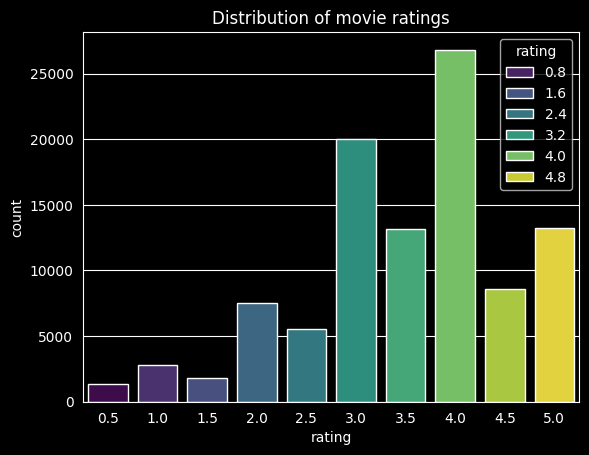

In [8]:
sns.countplot(x='rating', data=ratings, hue='rating', palette='viridis')
plt.title('Distribution of movie ratings')
plt.show()

We can see that our users are quite optimistic with their ratings, but that is normal and expected for this kind of data.

In [9]:
movie_ratings = ratings.merge(movies, on='movieId')
movie_ratings.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


Let's see which movies were rated the most.

In [10]:
movie_ratings['title'].value_counts()[0:5]

title
Forrest Gump (1994)                 329
Shawshank Redemption, The (1994)    317
Pulp Fiction (1994)                 307
Silence of the Lambs, The (1991)    279
Matrix, The (1999)                  278
Name: count, dtype: int64

The most popular movies were rated the most. This makes sense.\
Now let's find out which are the best and the worst rated movie in the dataset.

In [11]:
mean_ratings = ratings.groupby('movieId')[['rating']].mean()
mean_ratings.head()

,rating
movieId,
1,3.920930
2,3.431818
3,3.259615
4,2.357143
5,3.071429


In [12]:
lowest_rated = mean_ratings['rating'].idxmin()
movies[movies['movieId'] == lowest_rated]

,movieId,title,genres
2689,3604,Gypsy (1962),Musical


In [13]:
highest_rated = mean_ratings['rating'].idxmax()
movies[movies['movieId'] == highest_rated]

,movieId,title,genres
48,53,Lamerica (1994),Adventure|Drama


In [14]:
ratings[ratings['movieId'] == highest_rated]

,userId,movieId,rating,timestamp
13368,85,53,5.0,889468268
96115,603,53,5.0,963180003


_Lamerica_ has only two 5-star ratings so we should try another metrics, for example Bayesian average.

#### Bayesian average
is defined as

$r_i = \frac{C \times m + \sum \text{ratings}}{C + N}$

where $C$ represents confidence factor (the average number of ratings across all movies), $m$ represents the prior (the average mean rating across all movies) and $N$ is the total number of reviews for movie $i$.

After using Bayesian average, movies with fewer ratings will get "shrunk" toward the global average, while movies with many ratings will stay closer to their actual average.

In [15]:
movie_stats = ratings.groupby('movieId')['rating'].agg(['count', 'mean'])
movie_stats.head()

,count,mean
movieId,,
1,215,3.920930
2,110,3.431818
3,52,3.259615
4,7,2.357143
5,49,3.071429


In [16]:
C = movie_stats['count'].mean()
m = movie_stats['mean'].mean()

print(f'Average number of ratings per movie: {round(C, 2)}')
print(f'Average number of ratings per user: {round(m, 2)}')

Average number of ratings per movie: 10.37
Average number of ratings per user: 3.26


In [17]:
def bayesian_avg(ratings):
    calc = (C*m + ratings.sum())/(C + ratings.count())
    return round(calc, 2)

In [18]:
lamerica = ratings[ratings['movieId'] == highest_rated]['rating']
bayesian_avg(lamerica)

3.54

We can now see that _Lamerica_'s Bayesian average is $3.54$, which is more convincing.

In [19]:
bayesian_avgs = ratings.groupby('movieId')['rating'].agg(bayesian_avg).reset_index()
bayesian_avgs.columns = ['movieId', 'bayesian_avg']
bayesian_avgs.head()

,movieId,bayesian_avg
0,1,3.89
1,2,3.42
2,3,3.26
3,4,2.90
4,5,3.10


In [20]:
movie_stats = movie_stats.merge(bayesian_avgs, on='movieId')
movie_stats.head()

,movieId,count,mean,bayesian_avg
0,1,215,3.920930,3.89
1,2,110,3.431818,3.42
2,3,52,3.259615,3.26
3,4,7,2.357143,2.90
4,5,49,3.071429,3.10


In [21]:
movie_stats = movie_stats.merge(movies[['movieId', 'title']])
movie_stats.head()

,movieId,count,mean,bayesian_avg,title
0,1,215,3.920930,3.89,Toy Story (1995)
1,2,110,3.431818,3.42,Jumanji (1995)
2,3,52,3.259615,3.26,Grumpier Old Men (1995)
3,4,7,2.357143,2.90,Waiting to Exhale (1995)
4,5,49,3.071429,3.10,Father of the Bride Part II (1995)


In [22]:
movie_stats.drop('mean', axis=1, inplace=True)

In [23]:
movie_stats.sort_values(by='bayesian_avg', ascending=False)

,movieId,count,bayesian_avg,title
277,318,317,4.39,"Shawshank Redemption, The (1994)"
659,858,192,4.24,"Godfather, The (1972)"
2224,2959,218,4.23,Fight Club (1999)
921,1221,129,4.19,"Godfather: Part II, The (1974)"
46,50,204,4.19,"Usual Suspects, The (1995)"
...,...,...,...,...
1988,2643,16,2.31,Superman IV: The Quest for Peace (1987)
1144,1499,27,2.30,Anaconda (1997)
1372,1882,33,2.27,Godzilla (1998)
2679,3593,19,2.22,Battlefield Earth (2000)


We can now see that Bayesian average gives us a better sense of which movies are actually highly rated.

In [24]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [25]:
movies['genres'] = movies['genres'].apply(lambda x: x.split('|'))
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]"
1,2,Jumanji (1995),"[Adventure, Children, Fantasy]"
2,3,Grumpier Old Men (1995),"[Comedy, Romance]"
3,4,Waiting to Exhale (1995),"[Comedy, Drama, Romance]"
4,5,Father of the Bride Part II (1995),[Comedy]


In [26]:
from collections import Counter

genre_frequency = Counter(g for genres in movies['genres'] for g in genres)
print(f'There are {len(genre_frequency)} genres in total.')
genre_frequency

There are 20 genres in total.


Counter({'Drama': 4361,
         'Comedy': 3756,
         'Thriller': 1894,
         'Action': 1828,
         'Romance': 1596,
         'Adventure': 1263,
         'Crime': 1199,
         'Sci-Fi': 980,
         'Horror': 978,
         'Fantasy': 779,
         'Children': 664,
         'Animation': 611,
         'Mystery': 573,
         'Documentary': 440,
         'War': 382,
         'Musical': 334,
         'Western': 167,
         'IMAX': 158,
         'Film-Noir': 87,
         '(no genres listed)': 34})

In [27]:
genre_frequency_df = pd.DataFrame([genre_frequency]).T.reset_index()
genre_frequency_df.columns = ['genre', 'count']
genre_frequency_df

,genre,count
0,Adventure,1263
1,Animation,611
2,Children,664
3,Comedy,3756
4,Fantasy,779
5,Romance,1596
6,Drama,4361
7,Action,1828
8,Crime,1199
9,Thriller,1894


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],
 [Text(0, 0, 'Drama'),
  Text(1, 0, 'Comedy'),
  Text(2, 0, 'Thriller'),
  Text(3, 0, 'Action'),
  Text(4, 0, 'Romance'),
  Text(5, 0, 'Adventure'),
  Text(6, 0, 'Crime'),
  Text(7, 0, 'Sci-Fi'),
  Text(8, 0, 'Horror'),
  Text(9, 0, 'Fantasy'),
  Text(10, 0, 'Children'),
  Text(11, 0, 'Animation'),
  Text(12, 0, 'Mystery'),
  Text(13, 0, 'Documentary'),
  Text(14, 0, 'War'),
  Text(15, 0, 'Musical'),
  Text(16, 0, 'Western'),
  Text(17, 0, 'IMAX'),
  Text(18, 0, 'Film-Noir'),
  Text(19, 0, '(no genres listed)')])

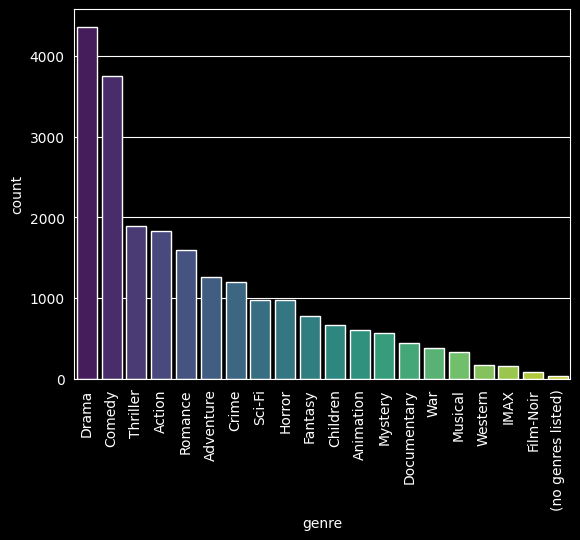

In [28]:
sns.barplot(x='genre', y='count', data=genre_frequency_df.sort_values(by='count', ascending=False), hue='genre', palette='viridis')
plt.xticks(rotation=90)

In [29]:
"""
    df_prep takes a dataframe as an argument and returns a sparse matrix,
    as well as user_map, movie_map, inv_user_map and inv_movie_map mappings.

    user_map - maps user id's to user indices
    movie_map - maps movie id's to movie indices
    inv_user_map - maps user indices to user id's
    inv_movie_map - maps movie indices to movie id's
"""

def df_prep(df):
    num_users = df['userId'].nunique()
    num_movies = df['movieId'].nunique()

    user_map = dict(zip(np.unique(df['userId']), list(range(num_users))))
    movie_map = dict(zip(np.unique(df['movieId']), list(range(num_movies))))

    inv_user_map = dict(zip(list(range(num_users)), np.unique(df['userId'])))
    inv_movie_map = dict(zip(list(range(num_movies)), np.unique(df['movieId'])))

    user_index = [user_map[i] for i in df['userId']]
    movie_index = [movie_map[i] for i in df['movieId']]

    X = csr_matrix((df['rating'], (user_index, movie_index)), shape=(num_users, num_movies))

    return X, user_map, movie_map, inv_user_map, inv_movie_map

X, user_map, movie_map, inv_user_map, inv_movie_map = df_prep(ratings)

In [30]:
X.shape

(610, 9724)

Our sparse matrix contains 610 users and 9724 movies.

In [31]:
n_total = X.shape[0]*X.shape[1]
n_ratings = X.nnz           # number of non-empty elements in the matrix (equals number of ratings in the dataset)
sparsity = 1 - n_ratings/n_total
print(f'Matrix sparsity: {round(sparsity*100, 2)}%')

Matrix sparsity: 98.3%


Sparsity is high but that is expected with this kind of dataset.\
We have to watch out for the cold-start problem that happens when there are new users and movies in the matrix that don't have ratings yet. Let's see which users and movies have only a few interactions.

In [32]:
num_ratings_per_user = X.getnnz(axis=1)
print(f'Most active user rated {num_ratings_per_user.max()} movies.')
print(f'Least active user rated {num_ratings_per_user.min()} movies.')

Most active user rated 2698 movies.
Least active user rated 20 movies.


In [33]:
num_ratings_per_movie = X.getnnz(axis=0)
print(f'Most rated movie has {num_ratings_per_movie.max()} ratings.')
print(f'Least rated movie has {num_ratings_per_movie.min()} ratings.')

Most rated movie has 329 ratings.
Least rated movie has 1 ratings.


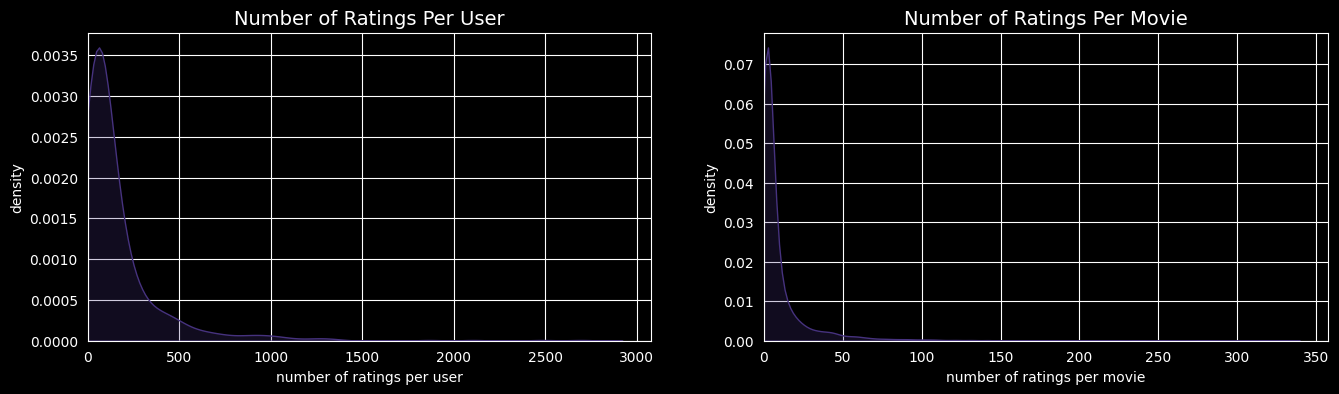

In [34]:
sns.set_palette('viridis')
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
sns.kdeplot(num_ratings_per_user, fill=True)
plt.xlim(0)
plt.title("Number of Ratings Per User", fontsize=14)
plt.xlabel("number of ratings per user")
plt.ylabel("density")
plt.subplot(1,2,2)
sns.kdeplot(num_ratings_per_movie, fill=True)
plt.xlim(0)
plt.title("Number of Ratings Per Movie", fontsize=14)
plt.xlabel("number of ratings per movie")
plt.ylabel("density")
plt.show()

### 3. Data preprocessing
Let's prepare our data for training. First we'll extract the release years from the movie title and attach them as a seperate column.

In [35]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]"
1,2,Jumanji (1995),"[Adventure, Children, Fantasy]"
2,3,Grumpier Old Men (1995),"[Comedy, Romance]"
3,4,Waiting to Exhale (1995),"[Comedy, Drama, Romance]"
4,5,Father of the Bride Part II (1995),[Comedy]


In [36]:
movies['year'] = (
    movies['title']
    .str.extract(r'\((\d{4})\)', expand=False)
    .astype(float)
)
movies.head()

,movieId,title,genres,year
0,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]",1995.0
1,2,Jumanji (1995),"[Adventure, Children, Fantasy]",1995.0
2,3,Grumpier Old Men (1995),"[Comedy, Romance]",1995.0
3,4,Waiting to Exhale (1995),"[Comedy, Drama, Romance]",1995.0
4,5,Father of the Bride Part II (1995),[Comedy],1995.0


Now let's turn every genre into a separate column.

In [37]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()
genre_encoded = pd.DataFrame(
    mlb.fit_transform(movies['genres']),
    columns=['genre_' + genre for genre in mlb.classes_],
    index=movies.index
)

movies = pd.concat([movies, genre_encoded], axis=1)
movies.drop('genres', axis=1, inplace=True)

print(f'Column names: {movies.columns}')

movies.head()

Column names: Index(['movieId', 'title', 'year', 'genre_(no genres listed)', 'genre_Action',
       'genre_Adventure', 'genre_Animation', 'genre_Children', 'genre_Comedy',
       'genre_Crime', 'genre_Documentary', 'genre_Drama', 'genre_Fantasy',
       'genre_Film-Noir', 'genre_Horror', 'genre_IMAX', 'genre_Musical',
       'genre_Mystery', 'genre_Romance', 'genre_Sci-Fi', 'genre_Thriller',
       'genre_War', 'genre_Western'],
      dtype='object')


,movieId,title,year,genre_(no genres listed),genre_Action,genre_Adventure,genre_Animation,genre_Children,genre_Comedy,genre_Crime,...,genre_Film-Noir,genre_Horror,genre_IMAX,genre_Musical,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Thriller,genre_War,genre_Western
0,1,Toy Story (1995),1995.0,0,0,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),1995.0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),1995.0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale (1995),1995.0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
4,5,Father of the Bride Part II (1995),1995.0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [38]:
movies.rename(columns={'genre_(no genres listed)': 'no_genre'}, inplace=True)
print(f'Column names: {movies.columns}')
movies.head()

Column names: Index(['movieId', 'title', 'year', 'no_genre', 'genre_Action',
       'genre_Adventure', 'genre_Animation', 'genre_Children', 'genre_Comedy',
       'genre_Crime', 'genre_Documentary', 'genre_Drama', 'genre_Fantasy',
       'genre_Film-Noir', 'genre_Horror', 'genre_IMAX', 'genre_Musical',
       'genre_Mystery', 'genre_Romance', 'genre_Sci-Fi', 'genre_Thriller',
       'genre_War', 'genre_Western'],
      dtype='object')


,movieId,title,year,no_genre,genre_Action,genre_Adventure,genre_Animation,genre_Children,genre_Comedy,genre_Crime,...,genre_Film-Noir,genre_Horror,genre_IMAX,genre_Musical,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Thriller,genre_War,genre_Western
0,1,Toy Story (1995),1995.0,0,0,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),1995.0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),1995.0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale (1995),1995.0,0,0,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
4,5,Father of the Bride Part II (1995),1995.0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [39]:
movies = movies.merge(movie_stats, on=['movieId', 'title'])
print(f'Column names: {movies.columns}')
movies.head()

Column names: Index(['movieId', 'title', 'year', 'no_genre', 'genre_Action',
       'genre_Adventure', 'genre_Animation', 'genre_Children', 'genre_Comedy',
       'genre_Crime', 'genre_Documentary', 'genre_Drama', 'genre_Fantasy',
       'genre_Film-Noir', 'genre_Horror', 'genre_IMAX', 'genre_Musical',
       'genre_Mystery', 'genre_Romance', 'genre_Sci-Fi', 'genre_Thriller',
       'genre_War', 'genre_Western', 'count', 'bayesian_avg'],
      dtype='object')


,movieId,title,year,no_genre,genre_Action,genre_Adventure,genre_Animation,genre_Children,genre_Comedy,genre_Crime,...,genre_IMAX,genre_Musical,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Thriller,genre_War,genre_Western,count,bayesian_avg
0,1,Toy Story (1995),1995.0,0,0,1,1,1,1,0,...,0,0,0,0,0,0,0,0,215,3.89
1,2,Jumanji (1995),1995.0,0,0,1,0,1,0,0,...,0,0,0,0,0,0,0,0,110,3.42
2,3,Grumpier Old Men (1995),1995.0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,52,3.26
3,4,Waiting to Exhale (1995),1995.0,0,0,0,0,0,1,0,...,0,0,0,1,0,0,0,0,7,2.90
4,5,Father of the Bride Part II (1995),1995.0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,49,3.10


In [40]:
# MinMax normalization for years
# TODO: something to consider, maybe convert to movie age (current_year - year) or use decades buckets

print(f'The oldest movies: {list(movies.loc[movies["year"] == movies["year"].min(), "title"])}')
print(f'The newest movies: {list(movies.loc[movies["year"] == movies["year"].max(), "title"])}')

movies['year'] = (
    (movies['year'] - movies['year'].min()) /
    (movies['year'].max() - movies['year'].min())
)

movies['year']

The oldest movies: ['Trip to the Moon, A (Voyage dans la lune, Le) (1902)']
The newest movies: ['Avengers: Infinity War - Part I (2018)', 'Annihilation (2018)', 'The Commuter (2018)', 'Insidious: The Last Key (2018)', 'Game Night (2018)', 'Maze Runner: The Death Cure (2018)', 'Isle of Dogs (2018)', 'The Clapper (2018)', 'Tom Segura: Disgraceful (2018)', 'When We First Met (2018)', 'The Cloverfield Paradox (2018)', 'Tomb Raider (2018)', 'Fred Armisen: Standup for Drummers (2018)', 'Death Wish (2018)', 'A Wrinkle in Time (2018)', 'Love, Simon (2018)', 'A Quiet Place (2018)', 'Alpha (2018)', 'I Kill Giants (2018)', 'Game Over, Man! (2018)', 'Blockers (2018)', 'Pacific Rim: Uprising (2018)', 'Rampage (2018)', 'Jurassic World: Fallen Kingdom (2018)', 'Incredibles 2 (2018)', 'Deadpool 2 (2018)', 'Solo: A Star Wars Story (2018)', "Won't You Be My Neighbor? (2018)", 'Sorry to Bother You (2018)', 'Ant-Man and the Wasp (2018)', 'Dogman (2018)', 'Mamma Mia: Here We Go Again! (2018)', 'Tag (2018)'

0       0.801724
1       0.801724
2       0.801724
3       0.801724
4       0.801724
          ...   
9719    0.991379
9720    0.991379
9721    0.991379
9722    1.000000
9723    0.767241
Name: year, Length: 9724, dtype: float64

In [41]:
# Normalizing the ratings' statistics
# TODO: maybe try log scaling for the normalization of the count column

max_rating = movies['count'].max()
if max_rating > 0:
    movies['count'] /= max_rating
else:
    movies['count'] = 0.0

movies['bayesian_avg'] = movies['bayesian_avg'] / 5.0

movies[['count', 'bayesian_avg']]

,count,bayesian_avg
0,0.653495,0.778
1,0.334347,0.684
2,0.158055,0.652
3,0.021277,0.580
4,0.148936,0.620
...,...,...
9719,0.003040,0.666
9720,0.003040,0.656
9721,0.003040,0.656
9722,0.003040,0.656


In [42]:
df = ratings.merge(movies, on='movieId', how='left')
df.drop('title', axis=1, inplace=True)
df.head()

,userId,movieId,rating,timestamp,year,no_genre,genre_Action,genre_Adventure,genre_Animation,genre_Children,...,genre_IMAX,genre_Musical,genre_Mystery,genre_Romance,genre_Sci-Fi,genre_Thriller,genre_War,genre_Western,count,bayesian_avg
0,1,1,4.0,964982703,0.801724,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0.653495,0.778
1,1,3,4.0,964981247,0.801724,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0.158055,0.652
2,1,6,4.0,964982224,0.801724,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0.310030,0.776
3,1,47,5.0,964983815,0.801724,0,0,0,0,0,...,0,0,1,0,0,1,0,0,0.617021,0.788
4,1,50,5.0,964982931,0.801724,0,0,0,0,0,...,0,0,1,0,0,1,0,0,0.620061,0.838


In [43]:
df.isna().sum()

userId                0
movieId               0
rating                0
timestamp             0
year                 18
no_genre              0
genre_Action          0
genre_Adventure       0
genre_Animation       0
genre_Children        0
genre_Comedy          0
genre_Crime           0
genre_Documentary     0
genre_Drama           0
genre_Fantasy         0
genre_Film-Noir       0
genre_Horror          0
genre_IMAX            0
genre_Musical         0
genre_Mystery         0
genre_Romance         0
genre_Sci-Fi          0
genre_Thriller        0
genre_War             0
genre_Western         0
count                 0
bayesian_avg          0
dtype: int64

In [44]:
df['year'] = df['year'].fillna(df['year'].median())
df.isna().sum().sum()

0

In [45]:
user_stats = ratings.groupby('userId').agg({
    'rating': ['mean', 'std', 'count', 'min', 'max'],
    'timestamp': ['min', 'max']
}).reset_index()

user_stats.columns = ['userId', 'avg_rating', 'rating_std', 'num_ratings', 'min_rating', 'max_rating', 'first_rating_time', 'last_rating_time']

user_stats.head()

,userId,avg_rating,rating_std,num_ratings,min_rating,max_rating,first_rating_time,last_rating_time
0,1,4.366379,0.800048,232,1.0,5.0,964980499,965719662
1,2,3.948276,0.805615,29,2.0,5.0,1445714835,1445715340
2,3,2.435897,2.090642,39,0.5,5.0,1306463323,1306464293
3,4,3.555556,1.314204,216,1.0,5.0,945078428,1007574542
4,5,3.636364,0.990441,44,1.0,5.0,847434747,847435337


In [46]:
user_stats['rating_range'] = user_stats['max_rating'] - user_stats['min_rating']
user_stats['rating_consistency'] = 1 / (user_stats['rating_std'] + 0.1)  # Avoid division by zero
user_stats['user_activity_days'] = (user_stats['last_rating_time'] - user_stats['first_rating_time']) / 86400
user_stats['ratings_per_day'] = user_stats['num_ratings'] / (user_stats['user_activity_days'] + 1)

user_stats.head()

,userId,avg_rating,rating_std,num_ratings,min_rating,max_rating,first_rating_time,last_rating_time,rating_range,rating_consistency,user_activity_days,ratings_per_day
0,1,4.366379,0.800048,232,1.0,5.0,964980499,965719662,4.0,1.111052,8.555127,24.280158
1,2,3.948276,0.805615,29,2.0,5.0,1445714835,1445715340,3.0,1.104223,0.005845,28.831483
2,3,2.435897,2.090642,39,0.5,5.0,1306463323,1306464293,4.5,0.456487,0.011227,38.567014
3,4,3.555556,1.314204,216,1.0,5.0,945078428,1007574542,4.0,0.707112,723.334653,0.298205
4,5,3.636364,0.990441,44,1.0,5.0,847434747,847435337,4.0,0.917061,0.006829,43.701575


In [47]:
movies = pd.read_csv('../data/ml-latest-small/movies.csv')
ratings_with_genres = ratings.merge(movies[['movieId', 'genres']], on='movieId')
ratings_with_genres

,userId,movieId,rating,timestamp,genres
0,1,1,4.0,964982703,Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Comedy|Romance
2,1,6,4.0,964982224,Action|Crime|Thriller
3,1,47,5.0,964983815,Mystery|Thriller
4,1,50,5.0,964982931,Crime|Mystery|Thriller
...,...,...,...,...,...
100831,610,166534,4.0,1493848402,Drama|Horror|Thriller
100832,610,168248,5.0,1493850091,Action|Crime|Thriller
100833,610,168250,5.0,1494273047,Horror
100834,610,168252,5.0,1493846352,Action|Sci-Fi


In [48]:
# Split genres and explode (one row per genre)
ratings_with_genres['genre_list'] = ratings_with_genres['genres'].str.split('|')
genre_exploded = ratings_with_genres.explode('genre_list')
genre_exploded

,userId,movieId,rating,timestamp,genres,genre_list
0,1,1,4.0,964982703,Adventure|Animation|Children|Comedy|Fantasy,Adventure
0,1,1,4.0,964982703,Adventure|Animation|Children|Comedy|Fantasy,Animation
0,1,1,4.0,964982703,Adventure|Animation|Children|Comedy|Fantasy,Children
0,1,1,4.0,964982703,Adventure|Animation|Children|Comedy|Fantasy,Comedy
0,1,1,4.0,964982703,Adventure|Animation|Children|Comedy|Fantasy,Fantasy
...,...,...,...,...,...,...
100834,610,168252,5.0,1493846352,Action|Sci-Fi,Sci-Fi
100835,610,170875,3.0,1493846415,Action|Crime|Drama|Thriller,Action
100835,610,170875,3.0,1493846415,Action|Crime|Drama|Thriller,Crime
100835,610,170875,3.0,1493846415,Action|Crime|Drama|Thriller,Drama


In [49]:
# Calculate average rating per genre for each user
user_genre_prefs = genre_exploded.groupby(['userId', 'genre_list']).agg({
    'rating': ['mean', 'count']
}).reset_index()

user_genre_prefs.columns = ['userId', 'genre', 'avg_rating_for_genre', 'genre_count']

user_genre_prefs.head()

,userId,genre,avg_rating_for_genre,genre_count
0,1,Action,4.322222,90
1,1,Adventure,4.388235,85
2,1,Animation,4.689655,29
3,1,Children,4.547619,42
4,1,Comedy,4.277108,83


In [50]:
# Each row of this table will store a user and his genre preferences
user_genre_matrix = user_genre_prefs.pivot_table(
    index='userId',
    columns='genre',
    values='avg_rating_for_genre',
    fill_value=0  # If user hasn't rated this genre, fill with 0
).reset_index()

# avg_{genre_name} - average rating for that genre by the user
user_genre_matrix.columns = ['userId'] + [f'avg_{col}' for col in user_genre_matrix.columns[1:]]

user_genre_matrix.head()

,userId,avg_(no genres listed),avg_Action,avg_Adventure,avg_Animation,avg_Children,avg_Comedy,avg_Crime,avg_Documentary,avg_Drama,...,avg_Film-Noir,avg_Horror,avg_IMAX,avg_Musical,avg_Mystery,avg_Romance,avg_Sci-Fi,avg_Thriller,avg_War,avg_Western
0,1,0.0,4.322222,4.388235,4.689655,4.547619,4.277108,4.355556,0.000000,4.529412,...,5.0,3.470588,0.000000,4.681818,4.166667,4.307692,4.225000,4.145455,4.500000,4.285714
1,2,0.0,3.954545,4.166667,0.000000,0.000000,4.000000,3.800000,4.333333,3.882353,...,0.0,3.000000,3.750000,0.000000,4.000000,4.500000,3.875000,3.700000,4.500000,3.500000
2,3,0.0,3.571429,2.727273,0.500000,0.500000,1.000000,0.500000,0.000000,0.750000,...,0.0,4.687500,0.000000,0.500000,5.000000,0.500000,4.200000,4.142857,0.500000,0.000000
3,4,0.0,3.320000,3.655172,4.000000,3.800000,3.509615,3.814815,4.000000,3.483333,...,4.0,4.250000,3.000000,4.000000,3.478261,3.379310,2.833333,3.552632,3.571429,3.800000
4,5,0.0,3.111111,3.250000,4.333333,4.111111,3.466667,3.833333,0.000000,3.800000,...,0.0,3.000000,3.666667,4.400000,4.000000,3.090909,2.500000,3.555556,3.333333,3.000000


In [51]:
# Each row of this table will a user and the number of times he has rated every genre
user_genre_count = user_genre_prefs.pivot_table(
    index='userId',
    columns='genre',
    values='genre_count',
    fill_value=0
).reset_index()

# count_{genre_name} - number of times a user has rated this genre
user_genre_count.columns = ['userId'] + [f'count_{col}' for col in user_genre_count.columns[1:]]

user_genre_count.head()

,userId,count_(no genres listed),count_Action,count_Adventure,count_Animation,count_Children,count_Comedy,count_Crime,count_Documentary,count_Drama,...,count_Film-Noir,count_Horror,count_IMAX,count_Musical,count_Mystery,count_Romance,count_Sci-Fi,count_Thriller,count_War,count_Western
0,1,0.0,90.0,85.0,29.0,42.0,83.0,45.0,0.0,68.0,...,1.0,17.0,0.0,22.0,18.0,26.0,40.0,55.0,22.0,7.0
1,2,0.0,11.0,3.0,0.0,0.0,7.0,10.0,3.0,17.0,...,0.0,1.0,4.0,0.0,2.0,1.0,4.0,10.0,1.0,1.0
2,3,0.0,14.0,11.0,4.0,5.0,9.0,2.0,0.0,16.0,...,0.0,8.0,0.0,1.0,1.0,5.0,15.0,7.0,5.0,0.0
3,4,0.0,25.0,29.0,6.0,10.0,104.0,27.0,2.0,120.0,...,4.0,4.0,1.0,16.0,23.0,58.0,12.0,38.0,7.0,10.0
4,5,0.0,9.0,8.0,6.0,9.0,15.0,12.0,0.0,25.0,...,0.0,1.0,3.0,5.0,1.0,11.0,2.0,9.0,3.0,2.0


In [52]:
# For each user, find his top 3 genres by count
top_genres = genre_exploded.groupby(['userId', 'genre_list']).size().reset_index(name='count')
top_genres = top_genres.sort_values(['userId', 'count'], ascending=[True, False])
top_genres_per_user = top_genres.groupby('userId').head(3)
top_genres_per_user.head(6)

,userId,genre_list,count
0,1,Action,90
1,1,Adventure,85
4,1,Comedy,83
22,2,Drama,17
17,2,Action,11
20,2,Crime,10


In [53]:
# This table will store a user and his top 3 genres
user_top_genres = top_genres_per_user.groupby('userId')['genre_list'].apply(list).reset_index()
user_top_genres.columns = ['userId', 'top_genres']
user_top_genres.head()

,userId,top_genres
0,1,"[Action, Adventure, Comedy]"
1,2,"[Drama, Action, Crime]"
2,3,"[Drama, Sci-Fi, Action]"
3,4,"[Drama, Comedy, Romance]"
4,5,"[Drama, Comedy, Crime]"


In [54]:
if not tags.empty:
    # How many tags per user
    user_tag_counts = tags.groupby('userId').size().reset_index(name='num_tags')

    user_top_tags = tags.groupby(['userId', 'tag']).size().reset_index(name='tag_count')
    user_top_tags = user_top_tags.sort_values(['userId', 'tag_count'], ascending=[True, False])

    # This table stores a user and his top 5 most used tags
    user_top_tags_list = user_top_tags.groupby('userId').head(5)['tag'].groupby(
        user_top_tags.groupby('userId').head(5)['userId']
    ).apply(list).reset_index()

    user_top_tags_list.columns = ['userId', 'favorite_tags']

    # How many unique tags per user
    user_tag_diversity = tags.groupby('userId')['tag'].nunique().reset_index()
    user_tag_diversity.columns = ['userId', 'tag_diversity']
else:
    # If there are no tags, create empty dataframes
    user_tag_counts = pd.DataFrame({'userId': ratings['userId'].unique(), 'num_tags': 0})
    user_top_tags_list = pd.DataFrame({'userId': ratings['userId'].unique(), 'favorite_tags': ''})
    user_tag_diversity = pd.DataFrame({'userId': ratings['userId'].unique(), 'tag_diversity': 0})

print("\n-- Number of tags per user:\n")
print(user_tag_counts.head())

print("-- Top 5 tags per user:\n")
print(user_top_tags_list.head(10))

print("\n-- Unique tags per user:\n")
print(user_tag_diversity.head())


-- Number of tags per user:

   userId  num_tags
0       2         9
1       7         1
2      18        16
3      21         4
4      49         3
-- Top 5 tags per user:

   userId                                      favorite_tags
0       2  [Boxing story, Highly quotable, Leonardo DiCap...
1       7                                     [way too long]
2      18  [Al Pacino, twist ending, Anthony Hopkins, Maf...
3      21        [bloody, painter, romantic comedy, wedding]
4      49                  [black hole, sci-fi, time-travel]
5      62     [funny, superhero, comedy, comic book, action]
6      63                            [classic, space action]
7      76                                   [action, sci-fi]
8     103  [great soundtrack, EPIC, good dialogue, non-li...
9     106           [Everything you want is here, adventure]

-- Unique tags per user:

   userId  tag_diversity
0       2              9
1       7              1
2      18             14
3      21              4
4 

In [55]:
# High/low rating tendency
user_rating_tendency = ratings.groupby('userId').agg(
    high_ratings_ratio=('rating', lambda x: (x >= 4.0).sum() / len(x)),
    low_ratings_ratio=('rating', lambda x: (x <= 2.0).sum() / len(x)),
    extreme_ratings_ratio=('rating', lambda x: ((x == 5.0) | (x == 1.0)).sum() / len(x))
).reset_index()

user_rating_tendency.head()

,userId,high_ratings_ratio,low_ratings_ratio,extreme_ratings_ratio
0,1,0.862069,0.025862,0.538793
1,2,0.655172,0.034483,0.206897
2,3,0.410256,0.538462,0.256410
3,4,0.592593,0.226852,0.402778
4,5,0.522727,0.090909,0.250000


In [56]:
# TODO: Normalize user_profile data
user_profile = user_stats.copy()
user_profile = user_profile.merge(user_genre_matrix, on='userId', how='left')
user_profile = user_profile.merge(user_genre_count, on='userId', how='left')
user_profile = user_profile.merge(user_tag_counts, on='userId', how='left')
user_profile = user_profile.merge(user_tag_diversity, on='userId', how='left')
user_profile = user_profile.merge(user_rating_tendency, on='userId', how='left')

# Save for later use
user_profile.to_csv('../data/user_profiles.csv', index=False)

print(f'There are {user_profile.shape[0]} users and {user_profile.shape[1]} features in total.')
print(f'User profile columns: {user_profile.columns}')
user_profile.head()

There are 610 users and 57 features in total.
User profile columns: Index(['userId', 'avg_rating', 'rating_std', 'num_ratings', 'min_rating',
       'max_rating', 'first_rating_time', 'last_rating_time', 'rating_range',
       'rating_consistency', 'user_activity_days', 'ratings_per_day',
       'avg_(no genres listed)', 'avg_Action', 'avg_Adventure',
       'avg_Animation', 'avg_Children', 'avg_Comedy', 'avg_Crime',
       'avg_Documentary', 'avg_Drama', 'avg_Fantasy', 'avg_Film-Noir',
       'avg_Horror', 'avg_IMAX', 'avg_Musical', 'avg_Mystery', 'avg_Romance',
       'avg_Sci-Fi', 'avg_Thriller', 'avg_War', 'avg_Western',
       'count_(no genres listed)', 'count_Action', 'count_Adventure',
       'count_Animation', 'count_Children', 'count_Comedy', 'count_Crime',
       'count_Documentary', 'count_Drama', 'count_Fantasy', 'count_Film-Noir',
       'count_Horror', 'count_IMAX', 'count_Musical', 'count_Mystery',
       'count_Romance', 'count_Sci-Fi', 'count_Thriller', 'count_War',
 

,userId,avg_rating,rating_std,num_ratings,min_rating,max_rating,first_rating_time,last_rating_time,rating_range,rating_consistency,...,count_Romance,count_Sci-Fi,count_Thriller,count_War,count_Western,num_tags,tag_diversity,high_ratings_ratio,low_ratings_ratio,extreme_ratings_ratio
0,1,4.366379,0.800048,232,1.0,5.0,964980499,965719662,4.0,1.111052,...,26.0,40.0,55.0,22.0,7.0,NaN,NaN,0.862069,0.025862,0.538793
1,2,3.948276,0.805615,29,2.0,5.0,1445714835,1445715340,3.0,1.104223,...,1.0,4.0,10.0,1.0,1.0,9.0,9.0,0.655172,0.034483,0.206897
2,3,2.435897,2.090642,39,0.5,5.0,1306463323,1306464293,4.5,0.456487,...,5.0,15.0,7.0,5.0,0.0,NaN,NaN,0.410256,0.538462,0.256410
3,4,3.555556,1.314204,216,1.0,5.0,945078428,1007574542,4.0,0.707112,...,58.0,12.0,38.0,7.0,10.0,NaN,NaN,0.592593,0.226852,0.402778
4,5,3.636364,0.990441,44,1.0,5.0,847434747,847435337,4.0,0.917061,...,11.0,2.0,9.0,3.0,2.0,NaN,NaN,0.522727,0.090909,0.250000
